In [1]:
import pandas as pd
import numpy as np
import math
import random
from collections import defaultdict
import matplotlib.pyplot as plt

LOC_PATH = "data/locations.csv"
TW_PATH  = "data/time_windows.csv"

# Tham số cố định theo đề bài
SPEED_KMH = 50.0                     # tốc độ tối đa (km/h)
DAYS = [1, 2, 3, 4, 5, 6, 7]          # 1=Thứ 2 ... 7=Chủ nhật


# Tham số cần hiệu chỉnh (giá trị mặc định, có thể grid-search)
DELTA = 0.03      # độ dốc sigmoid cho Slack
LAMBDA = 0.05     # độ dốc sigmoid cho Wait
TAU = 60          # ngưỡng trần thời gian chờ tối đa (phút)
W1, W2, W3 = 0.5, 0.3, 0.2   # trọng số Score(i):  w1*g_i + w2*h_i + w3*p_i
ALPHA, BETA = 0.6, 0.4       # trọng số Cost(sigma): alpha*Dist + beta*Wait (đã chuẩn hóa)

random.seed(42)
np.random.seed(42)

In [2]:
locations_df = pd.read_csv(LOC_PATH)
tw_df = pd.read_csv(TW_PATH)

print("Số điểm (kho + khách hàng):", locations_df.shape[0])
print("Số dòng time window:", tw_df.shape[0])
print(locations_df.head())
print(tw_df.head())

Số điểm (kho + khách hàng): 301
Số dòng time window: 1359
  location_id   location_name     x_km     y_km  demand_kg  service_time
0       DEPOT   Kho_Trung_Tam   0.0000   0.0000        0.0             0
1        C001  Khach_Hang_001 -11.7188  -9.1881        0.6             5
2        C002  Khach_Hang_002   9.7173  11.6111        0.6             5
3        C003  Khach_Hang_003   6.9787  10.1386        2.4             7
4        C004  Khach_Hang_004 -18.5445   8.8454        3.9             5
  location_id  day_of_week start_time end_time
0        C001            2      18:30    21:30
1        C001            3      18:30    21:30
2        C001            4      18:30    21:30
3        C001            5      18:30    21:30
4        C001            7      08:00    21:00


### Tiền xử lý: xây ma trận khoảng cách, dict time window, service time

In [3]:
def hhmm_to_min(s):
    """Chuyển 'HH:MM' sang số phút kể từ 00:00."""
    h, m = s.split(":")
    return int(h) * 60 + int(m)

# ----- Danh sách điểm -----
DEPOT_ID = locations_df.loc[locations_df["location_id"] == "DEPOT", "location_id"].iloc[0]
customer_ids = locations_df.loc[locations_df["location_id"] != DEPOT_ID, "location_id"].tolist()
all_ids = [DEPOT_ID] + customer_ids

coord = {row.location_id: (row.x_km, row.y_km) for row in locations_df.itertuples()}
service_time = {row.location_id: row.service_time for row in locations_df.itertuples()}
service_time[DEPOT_ID] = 0

# ----- Ma trận khoảng cách (công thức 1) -----
def euclid(i, j):
    xi, yi = coord[i]
    xj, yj = coord[j]
    return math.sqrt((xi - xj) ** 2 + (yi - yj) ** 2)

dist_matrix = {}
for i in all_ids:
    for j in all_ids:
        if i != j:
            dist_matrix[(i, j)] = euclid(i, j)

def dist(i, j):
    return dist_matrix[(i, j)]

# ----- Thời gian di chuyển (công thức 2), đơn vị: phút -----
def travel_time(i, j):
    return (dist(i, j) / SPEED_KMH) * 60.0

# ----- Time window: tw[customer][day] = list các (start_min, end_min), sắp xếp theo end tăng dần -----
tw = defaultdict(lambda: defaultdict(list))
for row in tw_df.itertuples():
    a = hhmm_to_min(row.start_time)
    b = hhmm_to_min(row.end_time)
    tw[row.location_id][row.day_of_week].append((a, b))

for cust in tw:
    for d in tw[cust]:
        tw[cust][d].sort(key=lambda w: w[1])   # sắp theo thời điểm đóng cửa tăng dần

print("Ví dụ time window của C001:", dict(tw["C001"]))

# Khung giờ làm việc trong ngày 
all_starts = [hhmm_to_min(s) for s in tw_df["start_time"]]
all_ends   = [hhmm_to_min(e) for e in tw_df["end_time"]]
WORKDAY_START = min(all_starts)
WORKDAY_END   = max(all_ends) + 30

Ví dụ time window của C001: {2: [(1110, 1290)], 3: [(1110, 1290)], 4: [(1110, 1290)], 5: [(1110, 1290)], 7: [(480, 1260)]}


### Hàm lõi: tìm khung giờ khả thi, mô phỏng thời gian route (công thức 3-8)

In [4]:
def fit_best_window(arrival, windows):
    """
    Công thức (4): chọn khung giờ khả thi sớm nhất (đóng cửa sớm nhất) mà arrival <= end.
    Trả về (a*, b*, wait, feasible)
    """
    for (a, b) in windows:
        if arrival <= b:
            wait = max(0.0, a - arrival)
            return a, b, wait, True
    return None, None, None, False


def simulate_route(route, day):
    """
    Mô phỏng toàn bộ route trong 1 ngày, áp dụng công thức (3)-(8).
    route: danh sách customer_id theo thứ tự thăm (không gồm depot)
    Trả về: (feasible, total_distance, total_wait, timeline)
    timeline: list các dict {customer, arrival, start_service, end_service, wait}
    """
    if not route:                      
        return True, 0.0, 0.0, []
    
    current_loc = DEPOT_ID
    current_time = WORKDAY_START
    total_distance = 0.0
    total_wait = 0.0
    timeline = []

    for cust in route:
        t_ij = travel_time(current_loc, cust)
        arrival = current_time + t_ij                       # (3)
        windows = tw[cust].get(day, [])
        a_star, b_star, wait, feasible = fit_best_window(arrival, windows)  # (4)
        if not feasible:
            return False, total_distance, total_wait, timeline

        start_service = max(arrival, a_star)                 # (5)
        wait_time = max(0.0, a_star - arrival)                # (6)
        end_service = start_service + service_time[cust]      # (7)

        if start_service > b_star:                            # (8) kiểm tra khả thi
            return False, total_distance, total_wait, timeline
        if end_service > WORKDAY_END:                          # ràng buộc giờ làm việc
            return False, total_distance, total_wait, timeline

        total_distance += dist(current_loc, cust)
        total_wait += wait_time
        timeline.append({
            "customer": cust, "arrival": arrival,
            "start_service": start_service, "end_service": end_service,
            "wait": wait_time
        })

        current_loc = cust
        current_time = end_service

    # cộng thêm quãng đường về kho (công thức 27)
    total_distance += dist(current_loc, DEPOT_ID)
    return True, total_distance, total_wait, timeline

### BASELINE 1: Luôn giao đến khách hàng gần nhất (Nearest Neighbor)

In [5]:
def baseline_nearest_neighbor_day(pending, day):
    """
    Baseline theo đề bài: 'luôn giao đến khách hàng gần nhất'.
    Xây route tham lam: mỗi bước chọn candidate feasible gần current_loc nhất.
    """
    current_loc = DEPOT_ID
    current_time = WORKDAY_START
    route = []
    served = []
    candidates = sorted(c for c in pending if tw[c].get(day))   # sorted + tie-break theo ID để tái lập kết quả

    while candidates:
        best = None
        best_dist = float("inf")

        for cust in candidates:
            t_ij = travel_time(current_loc, cust)
            arrival = current_time + t_ij
            a_star, b_star, wait, feasible = fit_best_window(arrival, tw[cust][day])
            if not feasible:
                continue
            end_service = max(arrival, a_star) + service_time[cust]
            if end_service > WORKDAY_END:
                continue
            d = dist(current_loc, cust)
            if d < best_dist:
                best_dist = d
                best = (cust, arrival, a_star, b_star)

        if best is None:
            break

        cust, arrival, a_star, b_star = best
        end_service = max(arrival, a_star) + service_time[cust]
        route.append(cust)
        served.append(cust)
        candidates.remove(cust)
        current_loc = cust
        current_time = end_service

    deferred = [c for c in pending if c not in served]
    return route, served, deferred


def run_weekly_baseline_nn(customer_ids):
    pending = set(customer_ids)
    schedule = {}
    for d in DAYS:
        if not pending:
            break
        route, served, _ = baseline_nearest_neighbor_day(pending, d)
        schedule[d] = route
        pending = pending - set(served)
        # loại các khách không còn TW hợp lệ trong các ngày còn lại -> vẫn giữ trong pending,
        # sẽ tự động rơi vào unfulfilled nếu hết tuần
    unfulfilled = pending
    return schedule, unfulfilled


schedule_nn, unfulfilled_nn = run_weekly_baseline_nn(customer_ids)
print("Baseline Nearest-Neighbor: số đơn không hoàn thành =", len(unfulfilled_nn))

Baseline Nearest-Neighbor: số đơn không hoàn thành = 92


### BASELINE 2: Luôn giao đơn có khung giờ kết thúc sớm nhất (Earliest Deadline First)

In [6]:
def baseline_edf_day(pending, day):
    """
    Baseline theo đề bài: 'luôn giao đơn có khung giờ kết thúc sớm nhất'.
    Mỗi bước chọn candidate có b* (giờ đóng cửa của khung giờ khả thi) nhỏ nhất.
    """
    current_loc = DEPOT_ID
    current_time = WORKDAY_START
    route = []
    served = []
    candidates = sorted(c for c in pending if tw[c].get(day))

    while candidates:
        best = None
        best_deadline = float("inf")

        for cust in candidates:
            t_ij = travel_time(current_loc, cust)
            arrival = current_time + t_ij
            a_star, b_star, wait, feasible = fit_best_window(arrival, tw[cust][day])
            if not feasible:
                continue
            end_service = max(arrival, a_star) + service_time[cust]
            if end_service > WORKDAY_END:
                continue
            if b_star < best_deadline:
                best_deadline = b_star
                best = (cust, arrival, a_star, b_star)

        if best is None:
            break

        cust, arrival, a_star, b_star = best
        end_service = max(arrival, a_star) + service_time[cust]
        route.append(cust)
        served.append(cust)
        candidates.remove(cust)
        current_loc = cust
        current_time = end_service

    deferred = [c for c in pending if c not in served]
    return route, served, deferred


def run_weekly_baseline_edf(customer_ids):
    pending = set(customer_ids)
    schedule = {}
    for d in DAYS:
        if not pending:
            break
        route, served, _ = baseline_edf_day(pending, d)
        schedule[d] = route
        pending = pending - set(served)
    unfulfilled = pending
    return schedule, unfulfilled


schedule_edf, unfulfilled_edf = run_weekly_baseline_edf(customer_ids)
print("Baseline Earliest-Deadline-First: số đơn không hoàn thành =", len(unfulfilled_edf))

Baseline Earliest-Deadline-First: số đơn không hoàn thành = 106


### BASELINE 3: Hạn chế tối đa việc hẹn lại khách sang ngày hôm sau

In [7]:
def baseline_min_defer_day(pending, day):
    """
    Baseline theo đề bài: 'hạn chế tối đa việc hẹn lại khách sang ngày hôm sau'.
    Chiến lược first-fit: cứ khách nào feasible thì chèn ngay (theo thứ tự ID gốc),
    không quan tâm tối ưu quãng đường/thời gian, chỉ ưu tiên tối đa số lượng phục vụ trong ngày.
    """
    current_loc = DEPOT_ID
    current_time = WORKDAY_START
    route = []
    served = []
    candidates = sorted([c for c in pending if tw[c].get(day)])   # thứ tự cố định (first-fit)

    changed = True
    while changed:
        changed = False
        for cust in list(candidates):
            t_ij = travel_time(current_loc, cust)
            arrival = current_time + t_ij
            a_star, b_star, wait, feasible = fit_best_window(arrival, tw[cust][day])
            if not feasible:
                continue
            end_service = max(arrival, a_star) + service_time[cust]
            if end_service > WORKDAY_END:
                continue
            # chèn ngay khách đầu tiên feasible tìm thấy (first-fit)
            route.append(cust)
            served.append(cust)
            candidates.remove(cust)
            current_loc = cust
            current_time = end_service
            changed = True
            break

    deferred = [c for c in pending if c not in served]
    return route, served, deferred


def run_weekly_baseline_min_defer(customer_ids):
    pending = set(customer_ids)
    schedule = {}
    for d in DAYS:
        if not pending:
            break
        route, served, _ = baseline_min_defer_day(pending, d)
        schedule[d] = route
        pending = pending - set(served)
    unfulfilled = pending
    return schedule, unfulfilled


schedule_md, unfulfilled_md = run_weekly_baseline_min_defer(customer_ids)
print("Baseline Min-Defer: số đơn không hoàn thành =", len(unfulfilled_md))

Baseline Min-Defer: số đơn không hoàn thành = 186


### THUẬT TOÁN CHÍNH: Multi-criteria Greedy Heuristic with Local Search (MCGHLS)

#### Các hàm chấm điểm Score(i) đã chuẩn hóa

In [8]:
def compute_scores(current_loc, current_time, candidates, day, delta, lam, tau, w1, w2, w3):
    """
    Tính Slack, Wait, khoảng cách cho từng candidate, áp dụng công thức (9)-(19).
    Trả về dict: cust -> (score, arrival, a_star, b_star, wait, end_service)
    """
    info = {}
    for cust in candidates:
        t_ij = travel_time(current_loc, cust)
        arrival = current_time + t_ij
        a_star, b_star, wait, feasible = fit_best_window(arrival, tw[cust][day])
        if not feasible:
            continue
        start_service = max(arrival, a_star)
        end_service = start_service + service_time[cust]
        if end_service > WORKDAY_END:
            continue
        slack = b_star - start_service                       # (9)
        d_ui = dist(current_loc, cust)
        info[cust] = {
            "arrival": arrival, "a_star": a_star, "b_star": b_star,
            "wait": wait, "slack": slack, "end_service": end_service,
            "d_ui": d_ui
        }

    if not info:
        return {}

    # ----- mu, nu tính động theo candidates hiện tại (công thức 10, 12) -----
    slacks_nonneg = [v["slack"] for v in info.values() if v["slack"] >= 0]
    waits_pos = [v["wait"] for v in info.values() if v["wait"] > 0]
    mu = np.mean(slacks_nonneg) if slacks_nonneg else 0.0
    nu = np.mean(waits_pos) if waits_pos else 0.0

    # ----- d_min, d_max để chuẩn hóa p_i (công thức 14) -----
    d_values = [v["d_ui"] for v in info.values()]
    d_min, d_max = min(d_values), max(d_values)
    eps = 1e-6

    scores = {}
    for cust, v in info.items():
        g_i = 1.0 / (1.0 + math.exp(delta * (v["slack"] - mu)))          # (11)
        h_i = 1.0 / (1.0 + math.exp(lam * (v["wait"] - nu)))              # (13)
        if d_max - d_min < eps:
            p_i = 1.0
        else:
            p_i = 1.0 - (v["d_ui"] - d_min) / (d_max - d_min + eps)       # (15)

        score = w1 * g_i + w2 * h_i + w3 * p_i                             # (19)
        scores[cust] = {**v, "score": score}

    return scores


def dynamic_max_wait(current_loc, candidates_info, tau):
    """
    Công thức (16): MaxWait(u) = min(tau, max travel time đến candidate xa nhất)
    """
    if not candidates_info:
        return tau
    max_t = max(v["d_ui"] / SPEED_KMH * 60.0 for v in candidates_info.values())
    return min(tau, max_t)

#### Xây route trong 1 ngày (cơ chế 2 tầng)

In [9]:
def build_daily_route_main(pending, day, delta=DELTA, lam=LAMBDA, tau=TAU, w1=W1, w2=W2, w3=W3):
    """
    Xây dựng lịch giao hàng cho 1 ngày theo thuật toán chính.
    Áp dụng công thức (16)-(18): ngưỡng chờ động + cơ chế chọn 2 tầng.
    """
    current_loc = DEPOT_ID
    current_time = WORKDAY_START
    route = []
    served = []
    candidates = sorted(c for c in pending if tw[c].get(day))   # sorted + tie-break theo ID để tái lập kết quả

    while candidates:
        scores = compute_scores(current_loc, current_time, candidates, day,
                                 delta, lam, tau, w1, w2, w3)
        if not scores:
            break   # không còn candidate nào khả thi hôm nay

        max_wait_u = dynamic_max_wait(current_loc, scores, tau)          # (16)
        active = {c: v for c, v in scores.items() if v["wait"] <= max_wait_u}   # (17)

        if active:                                                        # (18) - tầng 1
            best_cust = max(active.items(), key=lambda kv: kv[1]["score"])[0]
        else:                                                              # (18) - tầng 2
            best_cust = min(scores.items(), key=lambda kv: kv[1]["wait"])[0]

        info = scores[best_cust]
        route.append(best_cust)
        served.append(best_cust)
        candidates.remove(best_cust)
        current_loc = best_cust
        current_time = info["end_service"]

    deferred = [c for c in pending if c not in served]
    return route, served, deferred

#### Local Search cải thiện route (Or-opt, 2-opt, swap)

In [10]:
def route_cost(route, day, alpha=ALPHA, beta=BETA):
    """
    Công thức (27)-(29). Trả về (feasible, cost, dist, wait).
    Dist và Wait được chuẩn hóa min-max thô bằng cách chia cho một hằng số quy chiếu
    (đường chéo bản đồ và độ dài time window trung bình) để alpha, beta có ý nghĩa tỷ lệ.
    """
    feasible, d, w, _ = simulate_route(route, day)
    if not feasible:
        return False, float("inf"), d, w
    # chuẩn hóa thô: chia cho hằng số tham chiếu cố định để 2 đại lượng cùng độ lớn
    REF_DIST = 100.0     # km tham chiếu
    REF_WAIT = 200.0     # phút tham chiếu
    cost = alpha * (d / REF_DIST) + beta * (w / REF_WAIT)
    return True, cost, d, w


def local_search_improve(route, day, max_iter=200):
    """
    Áp dụng lần lượt Or-opt (dời 1 điểm), 2-opt (đảo đoạn), Swap (hoán đổi 2 điểm).
    Công thức (30): chỉ chấp nhận move nếu feasible và Cost giảm.
    """
    best_route = list(route)
    feasible, best_cost, _, _ = route_cost(best_route, day)
    if not feasible:
        return best_route   # route gốc đã infeasible (không nên xảy ra)

    improved = True
    n_iter = 0
    while improved and n_iter < max_iter:
        improved = False
        n_iter += 1
        k = len(best_route)
        if k < 2:
            break

        # ---- Or-opt: dời 1 khách sang vị trí khác ----
        for i in range(k):
            for j in range(k):
                if i == j:
                    continue
                new_route = best_route[:]
                cust = new_route.pop(i)
                new_route.insert(j, cust)
                feas, cost, _, _ = route_cost(new_route, day)
                if feas and cost < best_cost:
                    best_route, best_cost = new_route, cost
                    improved = True

        # ---- 2-opt: đảo ngược đoạn giữa 2 vị trí ----
        for i in range(k - 1):
            for j in range(i + 1, k):
                new_route = best_route[:i] + best_route[i:j + 1][::-1] + best_route[j + 1:]
                feas, cost, _, _ = route_cost(new_route, day)
                if feas and cost < best_cost:
                    best_route, best_cost = new_route, cost
                    improved = True

        # ---- Swap: hoán đổi 2 khách ----
        for i in range(k):
            for j in range(i + 1, k):
                new_route = best_route[:]
                new_route[i], new_route[j] = new_route[j], new_route[i]
                feas, cost, _, _ = route_cost(new_route, day)
                if feas and cost < best_cost:
                    best_route, best_cost = new_route, cost
                    improved = True

    return best_route

#### Vòng lặp lịch tuần hoàn chỉnh

In [11]:
def run_weekly_main_algorithm(customer_ids, delta=DELTA, lam=LAMBDA, tau=TAU,
                               w1=W1, w2=W2, w3=W3, use_local_search=True):
    pending = set(customer_ids)
    schedule = {}
    for d in DAYS:
        if not pending:
            break
        route, served, _ = build_daily_route_main(pending, d, delta, lam, tau, w1, w2, w3)
        if use_local_search and route:
            route = local_search_improve(route, d)
        schedule[d] = route
        pending = pending - set(served)
    unfulfilled = pending
    return schedule, unfulfilled


schedule_main, unfulfilled_main = run_weekly_main_algorithm(customer_ids)


#### Grid Search hiệu chỉnh delta, lambda, tau

In [12]:
def grid_search_params(customer_ids, val_ratio=0.3):
    """
    Grid search với hàm mục tiêu là Cost tổng hợp (không chỉ unfulfilled),
    vì fulfillment gần như bão hòa ở 100% với bộ dữ liệu hiện tại.
    """
    ids = list(customer_ids)
    random.shuffle(ids)
    n_val = max(30, int(len(ids) * val_ratio))   # đảm bảo tập val đủ lớn để có ý nghĩa thống kê
    val_ids = ids[:n_val]

    delta_grid = [0.01, 0.03, 0.05, 0.1]
    lambda_grid = [0.01, 0.03, 0.05, 0.1]
    tau_grid = [30, 60, 90, 120]

    results = []
    for d_ in delta_grid:
        for l_ in lambda_grid:
            for t_ in tau_grid:
                schedule, unfulfilled = run_weekly_main_algorithm(
                    val_ids, delta=d_, lam=l_, tau=t_, use_local_search=True  # bật local search
                )
                total_dist = 0.0
                total_wait = 0.0
                for d, route in schedule.items():
                    feasible, dd, ww, _ = simulate_route(route, d)
                    if feasible:
                        total_dist += dd
                        total_wait += ww

                # hàm mục tiêu tổng hợp: ưu tiên fulfillment trước, rồi đến cost vận hành
                REF_DIST, REF_WAIT = 100.0, 200.0
                objective = len(unfulfilled) * 10000 + ALPHA * (total_dist / REF_DIST) + BETA * (total_wait / REF_WAIT)

                results.append({
                    "delta": d_, "lambda": l_, "tau": t_,
                    "unfulfilled": len(unfulfilled),
                    "total_distance": total_dist,
                    "total_wait": total_wait,
                    "objective": objective
                })

    res_df = pd.DataFrame(results)

    # ----- Công thức (22): chọn objective nhỏ nhất -----
    # ----- Công thức (22'): nếu hòa (objective bằng nhau) -> chọn tau nhỏ nhất (Occam's razor) -----
    # Làm tròn objective trước khi so hòa để tránh sai số dấu phẩy động (vd 9.493153 vs 9.4931531)
    # khiến 2 tổ hợp "trông giống nhau" nhưng máy tính lại coi là khác nhau.
    res_df["objective_rounded"] = res_df["objective"].round(6)
    res_df = res_df.sort_values(
        by=["objective_rounded", "tau", "delta", "lambda"],
        ascending=[True, True, True, True]
    ).reset_index(drop=True)
    res_df = res_df.drop(columns=["objective_rounded"])

    best = res_df.iloc[0]

    print("Bộ tham số tốt nhất tìm được (đã áp dụng tie-break theo công thức 22'):\n", best)

    # Sensitivity về khả năng hoàn thành (feasibility landscape)  -- công thức (23a)
    n_feasible_combos = (res_df["unfulfilled"] == 0).sum()
    n_total_combos = len(res_df)
    print(f"Tỷ lệ tổ hợp tham số đạt unfulfilled=0: {n_feasible_combos}/{n_total_combos}")

    # Sensitivity về chất lượng route — chỉ tính trên các tổ hợp đã đạt unfulfilled=0 -- công thức (23b)
    feasible_df = res_df[res_df["unfulfilled"] == 0]
    obj_min = feasible_df["objective"].min()
    obj_max = feasible_df["objective"].max()
    sensitivity_quality = (obj_max - obj_min) / obj_min
    print(f"Sensitivity chất lượng (trong nhóm feasible): {sensitivity_quality:.3f}")
    print(feasible_df.sort_values("objective"))

    return best, res_df


best_params, grid_results = grid_search_params(customer_ids)
print("Thuật toán chính: số đơn không hoàn thành =", len(unfulfilled_main))


Bộ tham số tốt nhất tìm được (đã áp dụng tie-break theo công thức 22'):
 delta                0.030000
lambda               0.010000
tau                 60.000000
unfulfilled          0.000000
total_distance     640.092191
total_wait        2826.300068
objective            9.493153
Name: 0, dtype: float64
Tỷ lệ tổ hợp tham số đạt unfulfilled=0: 32/64
Sensitivity chất lượng (trong nhóm feasible): 0.004
    delta  lambda  tau  unfulfilled  total_distance   total_wait  objective
0    0.03    0.01   60            0      640.092191  2826.300068   9.493153
1    0.03    0.03   60            0      640.092191  2826.300068   9.493153
2    0.03    0.05   60            0      640.092191  2826.300068   9.493153
3    0.03    0.01   90            0      640.092191  2826.300068   9.493153
4    0.03    0.03   90            0      640.092191  2826.300068   9.493153
5    0.03    0.05   90            0      640.092191  2826.300068   9.493153
6    0.03    0.01  120            0      640.092191  2826.30006

In [13]:
schedule_main, unfulfilled_main = run_weekly_main_algorithm(
    customer_ids, delta=best_params["delta"], lam=best_params["lambda"], tau=best_params["tau"])
print("Thuật toán chính: số đơn không hoàn thành =", len(unfulfilled_main))

Thuật toán chính: số đơn không hoàn thành = 14


### Tính các chỉ số định lượng

In [14]:
def evaluate_schedule(schedule, unfulfilled, all_customers):
    """
    Tính: tỷ lệ hoàn thành, tổng quãng đường, tổng thời gian chờ, số lượt bị dời ngày.
    """
    total_dist = 0.0
    total_wait = 0.0
    n_deferred_events = 0
    served_so_far = set()

    for d in DAYS:
        route = schedule.get(d, [])
        if route:
            feasible, dd, ww, _ = simulate_route(route, d)
            if feasible:
                total_dist += dd
                total_wait += ww
            served_so_far |= set(route)

    # ước lượng số lượt dời ngày: khách chưa được phục vụ tính đến cuối mỗi ngày (trừ ngày cuối)
    pending = set(all_customers)
    for d in DAYS[:-1]:
        route = set(schedule.get(d, []))
        pending -= route
        n_deferred_events += len(pending)

    n_total = len(all_customers)
    n_unfulfilled = len(unfulfilled)
    fulfill_rate = (n_total - n_unfulfilled) / n_total

    return {
        "fulfillment_rate": fulfill_rate,
        "total_distance_km": total_dist,
        "total_wait_min": total_wait,
        "n_unfulfilled": n_unfulfilled,
        "n_deferred_events": n_deferred_events
    }


metrics_nn   = evaluate_schedule(schedule_nn, unfulfilled_nn, customer_ids)
metrics_edf  = evaluate_schedule(schedule_edf, unfulfilled_edf, customer_ids)
metrics_md   = evaluate_schedule(schedule_md, unfulfilled_md, customer_ids)
metrics_main = evaluate_schedule(schedule_main, unfulfilled_main, customer_ids)

comparison_df = pd.DataFrame({
    "Nearest-Neighbor": metrics_nn,
    "Earliest-Deadline": metrics_edf,
    "Min-Defer": metrics_md,
    "MCGHLS": metrics_main
}).T

comparison_df

,fulfillment_rate,total_distance_km,total_wait_min,n_unfulfilled,n_deferred_events
Nearest-Neighbor,0.693333,807.552836,3319.024988,92.0,1307.0
Earliest-Deadline,0.646667,3431.601515,638.390281,106.0,1167.0
Min-Defer,0.380000,2266.636650,2669.221405,186.0,1538.0
MCGHLS,0.953333,1216.144832,1568.677636,14.0,702.0


### So sánh các chỉ số định lượng

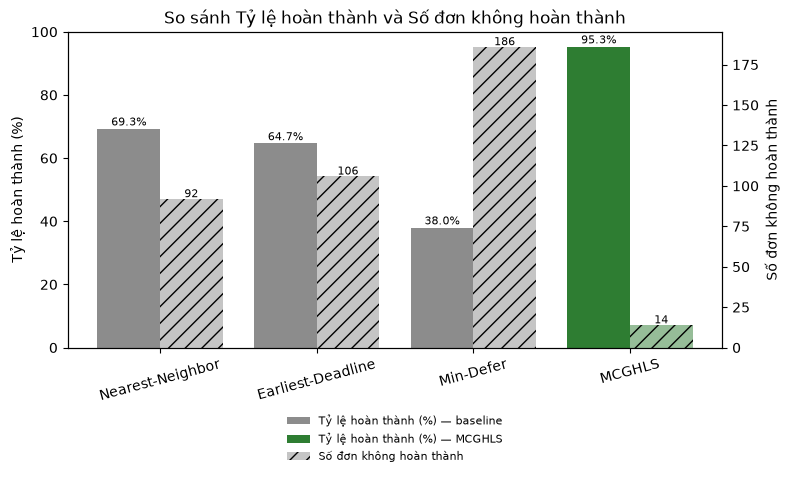

In [15]:
labels = comparison_df.index.tolist()
colors = ["#8c8c8c", "#8c8c8c", "#8c8c8c", "#2e7d32"]   # baseline xám, thuật toán chính xanh

# Chỉ trực quan hóa 2 chỉ số ưu tiên hàng đầu (Fulfillment % và Unfulfilled),
# vì Distance/Wait đã được trình bày đầy đủ và rõ ràng trong bảng so sánh (comparison_df)
# nên không cần lặp lại bằng biểu đồ.

fig, ax1 = plt.subplots(figsize=(8, 5))

x = range(len(labels))
width = 0.4

bars1 = ax1.bar([i - width/2 for i in x], comparison_df["fulfillment_rate"] * 100,
                width=width, color=colors, label="Tỷ lệ hoàn thành (%)")
ax1.set_ylabel("Tỷ lệ hoàn thành (%)")
ax1.set_ylim(0, 100)
for i, v in enumerate(comparison_df["fulfillment_rate"] * 100):
    ax1.text(i - width/2, v + 1, f"{v:.1f}%", ha="center", fontsize=8)

ax2 = ax1.twinx()
bars2 = ax2.bar([i + width/2 for i in x], comparison_df["n_unfulfilled"],
                width=width, color=colors, alpha=0.5, hatch="//", label="Số đơn không hoàn thành")
ax2.set_ylabel("Số đơn không hoàn thành")
for i, v in enumerate(comparison_df["n_unfulfilled"]):
    ax2.text(i + width/2, v + 1, f"{v:.0f}", ha="center", fontsize=8)

ax1.set_xticks(list(x))
ax1.set_xticklabels(labels, rotation=15)
ax1.set_title("So sánh Tỷ lệ hoàn thành và Số đơn không hoàn thành")

# chú thích thủ công: cột đặc = fulfillment, cột gạch chéo = unfulfilled
from matplotlib.patches import Patch
legend_elems = [
    Patch(facecolor="#8c8c8c", label="Tỷ lệ hoàn thành (%) — baseline"),
    Patch(facecolor="#2e7d32", label="Tỷ lệ hoàn thành (%) — MCGHLS"),
    Patch(facecolor="#8c8c8c", alpha=0.5, hatch="//", label="Số đơn không hoàn thành"),
]
ax1.legend(handles=legend_elems, loc="upper center", bbox_to_anchor=(0.5, -0.18), ncol=1, fontsize=8, frameon=False)

plt.tight_layout()
plt.savefig("output/comparison_metrics.png", dpi=150, bbox_inches="tight")
plt.show()
